# Data Inspection and Cleaning





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df=pd.read_excel("/content/youtube_user_data_2.xlsx")
df

,user_id,age,gender,country,signup_date,last_active_date,subscription_type,avg_daily_watch_time_2024,total_videos_watched_2023,total_videos_watched_2024,total_comments_2023,total_comments_2024,total_likes_2023,total_likes_2024,total_subscriptions_2024,preferred_content_2023,preferred_content_2024,recommendations_clicked_2023,recommendations_clicked_2024
0,1,51,Male,Germany,2022-10-10,2024-12-28,Free,207,570.0,1812.0,118,255,167,232,12,Music,How-to,35,64
1,2,64,Female,Germany,2020-11-07,2024-12-30,Free,293,859.0,971.0,29,93,3,6,28,Vlogs,How-to,46,86
2,3,41,Male,Germany,2012-07-22,2024-12-31,Free,21,287.0,379.0,39,18,104,168,5,Entertainment,Vlogs,141,58
3,4,27,Female,Germany,2019-11-08,2024-12-22,Free,151,929.0,1902.0,1,201,104,240,23,News,Music,89,62
4,5,55,Male,Germany,2018-11-08,2024-12-30,Free,246,131.0,729.0,121,87,103,1,0,News,Entertainment,83,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000,997,36,Male,Germany,2015-06-15,2024-12-24,Free,160,590.0,1188.0,90,84,1,89,9,How-to,How-to,13,3
1001,998,17,Male,Germany,2012-12-03,2024-12-22,Free,53,593.0,421.0,37,43,368,1,26,Entertainment,Entertainment,44,175
1002,998,17,Male,Germany,2012-12-03,2024-12-22,Free,53,593.0,421.0,37,43,368,1,26,Entertainment,Entertainment,44,175
1003,999,46,Female,Germany,2014-04-27,2024-12-25,Free,224,2856.0,165.0,112,255,416,741,6,How-to,How-to,165,63


In [ ]:
#Check number of duplicate values
df.duplicated().sum()

5

In [ ]:
#Remove duplicate
df1 = df.drop_duplicates().copy()
df1

,user_id,age,gender,country,signup_date,last_active_date,subscription_type,avg_daily_watch_time_2024,total_videos_watched_2023,total_videos_watched_2024,total_comments_2023,total_comments_2024,total_likes_2023,total_likes_2024,total_subscriptions_2024,preferred_content_2023,preferred_content_2024,recommendations_clicked_2023,recommendations_clicked_2024
0,1,51,Male,Germany,2022-10-10,2024-12-28,Free,207,570.0,1812.0,118,255,167,232,12,Music,How-to,35,64
1,2,64,Female,Germany,2020-11-07,2024-12-30,Free,293,859.0,971.0,29,93,3,6,28,Vlogs,How-to,46,86
2,3,41,Male,Germany,2012-07-22,2024-12-31,Free,21,287.0,379.0,39,18,104,168,5,Entertainment,Vlogs,141,58
3,4,27,Female,Germany,2019-11-08,2024-12-22,Free,151,929.0,1902.0,1,201,104,240,23,News,Music,89,62
4,5,55,Male,Germany,2018-11-08,2024-12-30,Free,246,131.0,729.0,121,87,103,1,0,News,Entertainment,83,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999,996,32,Male,Germany,2020-11-14,2024-12-23,Premium,286,1740.0,2849.0,195,23,188,349,16,Gaming,Vlogs,128,29
1000,997,36,Male,Germany,2015-06-15,2024-12-24,Free,160,590.0,1188.0,90,84,1,89,9,How-to,How-to,13,3
1001,998,17,Male,Germany,2012-12-03,2024-12-22,Free,53,593.0,421.0,37,43,368,1,26,Entertainment,Entertainment,44,175
1003,999,46,Female,Germany,2014-04-27,2024-12-25,Free,224,2856.0,165.0,112,255,416,741,6,How-to,How-to,165,63


In [ ]:
#Show information
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1004
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   user_id                       1000 non-null   int64         
 1   age                           1000 non-null   int64         
 2   gender                        1000 non-null   object        
 3   country                       1000 non-null   object        
 4   signup_date                   1000 non-null   datetime64[ns]
 5   last_active_date              1000 non-null   datetime64[ns]
 6   subscription_type             1000 non-null   object        
 7   avg_daily_watch_time_2024     1000 non-null   int64         
 8   total_videos_watched_2023     999 non-null    float64       
 9   total_videos_watched_2024     999 non-null    float64       
 10  total_comments_2023           1000 non-null   int64         
 11  total_comments_2024           1000 

In [ ]:
#replace null value with mean
df1['total_videos_watched_2023'] = df1['total_videos_watched_2023'].fillna(df1['total_videos_watched_2023'].median())
df1['total_videos_watched_2024'] = df1['total_videos_watched_2024'].fillna(df1['total_videos_watched_2024'].median())

#Change the total_videos_watched to integer format
df1['total_videos_watched_2023'] = df1['total_videos_watched_2023'].astype(int)
df1['total_videos_watched_2024'] = df1['total_videos_watched_2024'].astype(int)
df1.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
signup_date,datetime64[ns]
last_active_date,datetime64[ns]
subscription_type,object
avg_daily_watch_time_2024,int64
total_videos_watched_2023,int64
total_videos_watched_2024,int64


In [ ]:
#Remove irrelevant columns
df1 = df1.drop(['country','last_active_date','signup_date','user_id'], axis=1)
df1

,age,gender,subscription_type,avg_daily_watch_time_2024,total_videos_watched_2023,total_videos_watched_2024,total_comments_2023,total_comments_2024,total_likes_2023,total_likes_2024,total_subscriptions_2024,preferred_content_2023,preferred_content_2024,recommendations_clicked_2023,recommendations_clicked_2024
0,51,Male,Free,207,570,1812,118,255,167,232,12,Music,How-to,35,64
1,64,Female,Free,293,859,971,29,93,3,6,28,Vlogs,How-to,46,86
2,41,Male,Free,21,287,379,39,18,104,168,5,Entertainment,Vlogs,141,58
3,27,Female,Free,151,929,1902,1,201,104,240,23,News,Music,89,62
4,55,Male,Free,246,131,729,121,87,103,1,0,News,Entertainment,83,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999,32,Male,Premium,286,1740,2849,195,23,188,349,16,Gaming,Vlogs,128,29
1000,36,Male,Free,160,590,1188,90,84,1,89,9,How-to,How-to,13,3
1001,17,Male,Free,53,593,421,37,43,368,1,26,Entertainment,Entertainment,44,175
1003,46,Female,Free,224,2856,165,112,255,416,741,6,How-to,How-to,165,63


In [ ]:
print(df1.describe().round(0))

          age  avg_daily_watch_time_2024  total_videos_watched_2023  \
count  1000.0                     1000.0                     1000.0   
mean     41.0                      180.0                     1254.0   
std      16.0                       79.0                      763.0   
min      13.0                       15.0                      100.0   
25%      28.0                      116.0                      616.0   
50%      41.0                      192.0                     1155.0   
75%      55.0                      246.0                     1808.0   
max      69.0                      300.0                     2997.0   

       total_videos_watched_2024  total_comments_2023  total_comments_2024  \
count                     1000.0               1000.0               1000.0   
mean                      1429.0                112.0                115.0   
std                       1053.0                 66.0                 76.0   
min                        106.0                

<Axes: >

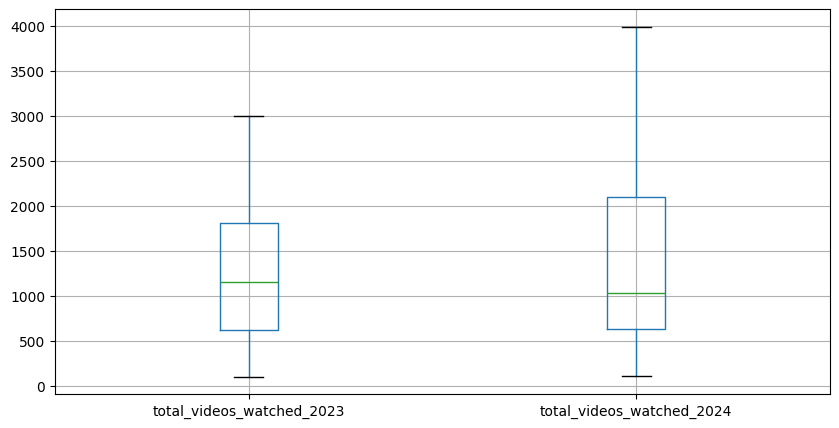

In [ ]:
#visualize the distribution, patterns and potential outliers of data using boxplot
df1.boxplot(column=['total_videos_watched_2023','total_videos_watched_2024'],figsize=(10,5))

<Axes: >

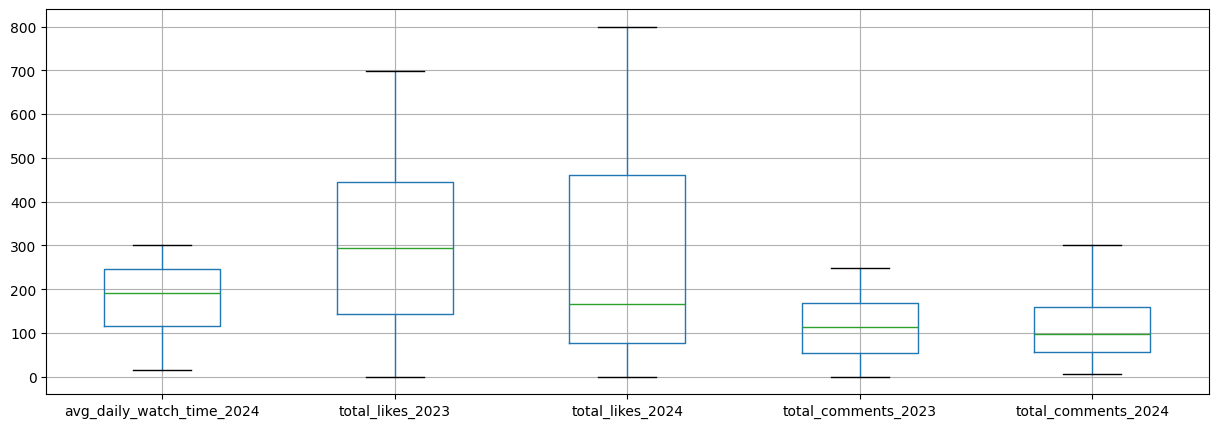

In [ ]:
df1.boxplot(column=['avg_daily_watch_time_2024','total_likes_2023','total_likes_2024','total_comments_2023','total_comments_2024'],figsize=(15,5))

<Axes: >

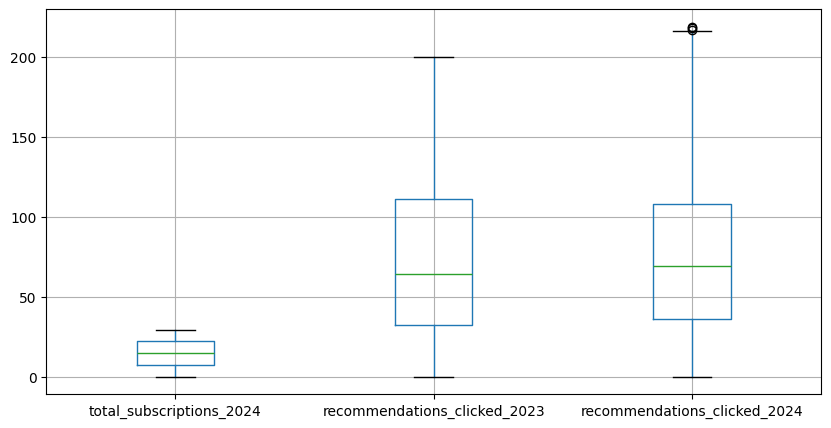

In [ ]:
df1.boxplot(column=['total_subscriptions_2024','recommendations_clicked_2023','recommendations_clicked_2024'],figsize=(10,5))

In [ ]:
#Count the number of ouliers in recommendation clicked
#Define the function to find outliers
def find_outliers(df,column):
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  outliers=df[(df[column]<lower_bound) | (df[column]>upper_bound)]
  return outliers

outliers = find_outliers(df1,'recommendations_clicked_2024')
print('Number of Outliers:',len(outliers))

Number of Outliers: 3


# Data Analysis

In [ ]:
#Create a new column for age group
age_labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65 and over']
df1['age_group'] = pd.cut(df1['age'], bins=7, labels=age_labels, right=False)
df1

,age,gender,subscription_type,avg_daily_watch_time_2024,total_videos_watched_2023,total_videos_watched_2024,total_comments_2023,total_comments_2024,total_likes_2023,total_likes_2024,total_subscriptions_2024,preferred_content_2023,preferred_content_2024,recommendations_clicked_2023,recommendations_clicked_2024,age_group
0,51,Male,Free,207,570,1812,118,255,167,232,12,Music,How-to,35,64,45-54
1,64,Female,Free,293,859,971,29,93,3,6,28,Vlogs,How-to,46,86,65 and over
2,41,Male,Free,21,287,379,39,18,104,168,5,Entertainment,Vlogs,141,58,35-44
3,27,Female,Free,151,929,1902,1,201,104,240,23,News,Music,89,62,18-24
4,55,Male,Free,246,131,729,121,87,103,1,0,News,Entertainment,83,42,55-64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999,32,Male,Premium,286,1740,2849,195,23,188,349,16,Gaming,Vlogs,128,29,25-34
1000,36,Male,Free,160,590,1188,90,84,1,89,9,How-to,How-to,13,3,25-34
1001,17,Male,Free,53,593,421,37,43,368,1,26,Entertainment,Entertainment,44,175,Under 18
1003,46,Female,Free,224,2856,165,112,255,416,741,6,How-to,How-to,165,63,45-54


In [ ]:
#distribution by age group
fig_age = px.pie(df1, names='age_group', title = 'Contribution by Age Group')
fig_age.update_layout(width=600, height=500)
fig_age.update_traces(textposition='inside', textinfo='percent+label')
fig_age.update_layout(showlegend=False)
fig_age.show()

In [ ]:
#Distribution by Gender
fig_gen = px.pie(df1, names='gender', title = 'Contribution by Gender')
fig_gen.update_layout(width=600, height=500)
fig_gen.show()

In [ ]:
#Distribution by Subscription Type
fig_subs = px.pie(df1, names='subscription_type', title = 'Contribution by Subscription Type')
fig_subs.update_layout(width=600, height=500)
fig_subs.update_traces(textposition='inside', textinfo='percent+label')
fig_subs.update_layout(showlegend=False)
fig_subs.show()

<ipython-input-17-c164984e496e>:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



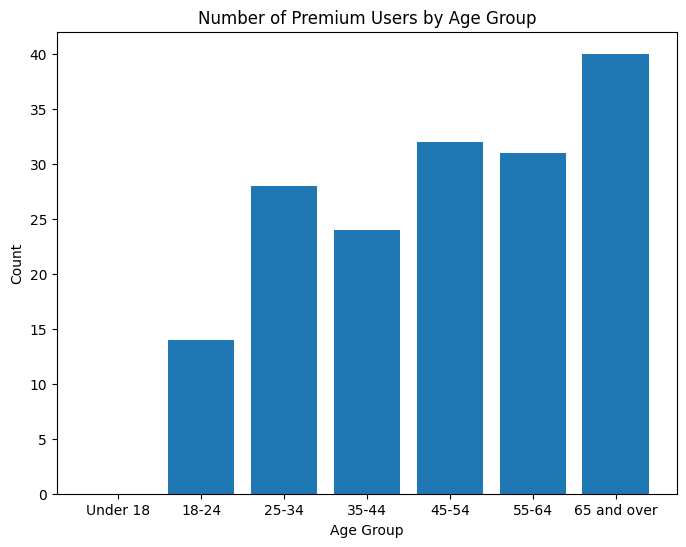

In [ ]:
#Which age group more upgrade to Premium?
premium_users = df1[df1['subscription_type'] == 'Premium'] #Filter the dataset to include only rows where 'subscription_type' = 'Premium'

#Aggregate the data by 'age_group' and count the number of 'Premium' users
premium_by_age = premium_users.groupby('age_group').size().reset_index(name='count')

#focus age group for Premium subscription
plt.figure(figsize=(8, 6))
plt.bar(x=premium_by_age['age_group'], height=premium_by_age['count'])
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Number of Premium Users by Age Group')
plt.show()

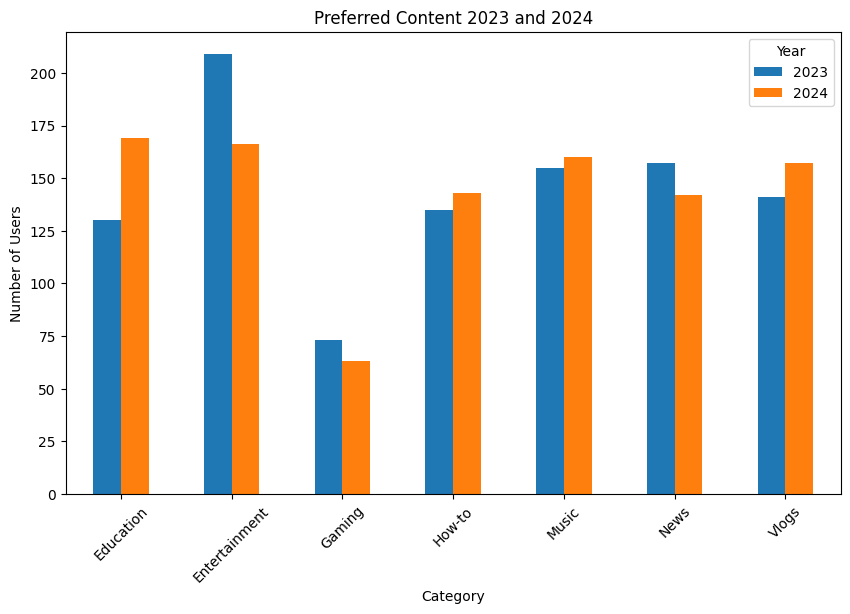

In [ ]:
#calculate the preferred content for 2023 and 2024 by counting
content_2023 = df1['preferred_content_2023'].value_counts()
content_2024 = df1['preferred_content_2024'].value_counts()

#create a DataFrame for plotting
content_comparison = pd.DataFrame({'2023': content_2023, '2024': content_2024})

#plot the bar chart
content_comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Preferred Content 2023 and 2024')
plt.xlabel('Category')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.show()

In [ ]:
#preferred content by age group
content_by_age = df1.groupby('age_group')['preferred_content_2024'].value_counts().reset_index(name='count')
#plot group bar chart
fig_content_age = px.bar(content_by_age, x='age_group', y='count', color='preferred_content_2024', barmode='group', width= 2000, height=800)
fig_content_age.show()

<ipython-input-19-c54aca410251>:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



!!! cannot compare cross age group, this chart is also effected by the age group distribution
*  Under 18 group mainly search for entertaining videos on youtube like gaming, music and entertainment
*  18-24 focuses more on entertainment and education
the news category is more preferred by the older group
*  Vlogs is top category for 35-54
*  How-to is the leading cat for 25-34 and over 64 age

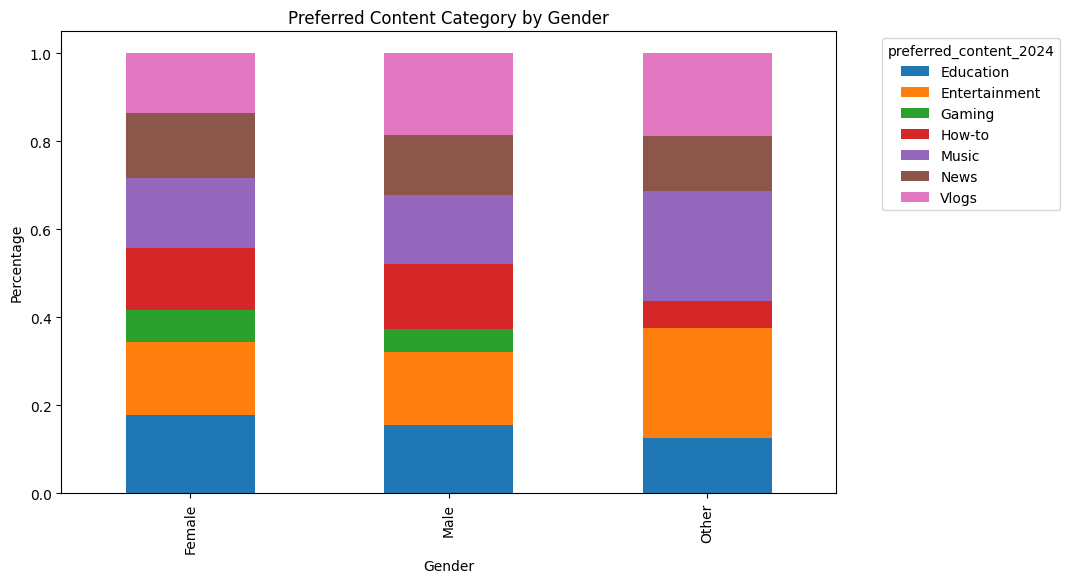

In [ ]:
#preferred content by gender
content_by_gender = df1.groupby('gender')['preferred_content_2024'].value_counts().reset_index(name='count')

# Create a pivot table
content_by_gender_pivot = content_by_gender.pivot(index='gender', columns='preferred_content_2024', values='count')

# Normalize the data to 100%
content_by_gender_pct = content_by_gender_pivot.div(content_by_gender_pivot.sum(axis=1), axis=0)

# Create the 100% stacked bar chart
ax = content_by_gender_pct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Preferred Content Category by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')
#move the legend outside the plot
ax.legend_.set_bbox_to_anchor((1.05, 1))
ax.legend_.set_loc('upper left')

plt.show()

In [ ]:
#average watch time by age
watch_time_by_age = df1.groupby('age_group')['avg_daily_watch_time_2024'].mean()
#plot bar chart
fig_watch_time_age = px.bar(watch_time_by_age, x=watch_time_by_age.index, y=watch_time_by_age.values)
fig_watch_time_age.update_layout(title='Average Daily Watch Time by Age Group', xaxis_title='Age Group', yaxis_title='Average Watch Time (minutes)', width= 800, height=600)
fig_watch_time_age.show()

<ipython-input-21-820b3b5b80ec>:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
#total subscription by age
subscription_by_age = df1.groupby('age_group')['total_subscriptions_2024'].mean()
#plot a bar chart
fig_subscription_age = px.bar(subscription_by_age, x=subscription_by_age.index, y=subscription_by_age.values)
fig_subscription_age.update_layout(title='Average Channels Subscribed by Age Group', xaxis_title='Age Group', yaxis_title='Average Subscriptions',width= 800, height=600)
fig_subscription_age.show()

<ipython-input-22-7791cdb0c26b>:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
#videos by age
videos_by_age = df1.groupby('age_group')[['total_videos_watched_2023', 'total_videos_watched_2024']].mean().reset_index()
#plot a bar chart to compared the total videos watched 2023 vs 2024
fig_video_23_24 = px.bar(videos_by_age, x='age_group', y=['total_videos_watched_2023', 'total_videos_watched_2024'], barmode='group', width= 1200, height=600)
fig_video_23_24.update_layout(title='Average Videos Watched 2023 vs 2024', xaxis_title='Age Group', yaxis_title='Total Videos')
fig_video_23_24.show()

<ipython-input-23-7b944accc7a3>:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
#comments by age
comments_by_age = df1.groupby('age_group')[['total_comments_2023', 'total_comments_2024']].mean().reset_index()
#plot bar chart
fig_comments_23_24 = px.bar(comments_by_age, x='age_group', y=['total_comments_2023', 'total_comments_2024'], barmode='group', width= 1200, height=600)
fig_comments_23_24.update_layout(title='Average Comments 2023 vs 2024', xaxis_title='Age Group', yaxis_title='Total Comments')
fig_comments_23_24.show()

<ipython-input-24-004831214432>:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
#likes by age
like_by_age = df1.groupby('age_group')[['total_likes_2023', 'total_likes_2024']].mean().reset_index()
#plot bar chart
fig_like_23_24 = px.bar(like_by_age, x='age_group', y=['total_likes_2023', 'total_likes_2024'], barmode='group', width= 1200, height=600)
fig_like_23_24.update_layout(title='Average Likes 2023 vs 2024', xaxis_title='Age Group', yaxis_title='Total Likes')
fig_like_23_24.show()

<ipython-input-25-3f1ac6b0b223>:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
#recommendation clicked by age
click_by_age = df1.groupby('age_group')[['recommendations_clicked_2023', 'recommendations_clicked_2024']].mean().reset_index()
#plot bar chart
fig_click_23_24 = px.bar(click_by_age, x='age_group', y=['recommendations_clicked_2023', 'recommendations_clicked_2024'], barmode='group', width= 1200, height=600)
fig_click_23_24.update_layout(title='Average Recommendation Clicked 2023 vs 2024', xaxis_title='Age Group', yaxis_title='Total Clicks')
fig_click_23_24.show()

<ipython-input-26-e32fa949bdd3>:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



# Data Transformation


In [ ]:
#Encoding categorical attributes using OneHot Encoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_cols = encoder.fit_transform(df1[['age_group','gender', 'subscription_type', 'preferred_content_2023', 'preferred_content_2024']])
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(['age_group','gender', 'subscription_type', 'preferred_content_2023', 'preferred_content_2024']))

# Concatenate the encoded DataFrame with the original DataFrame
df2 = pd.concat([df1, encoded_df], axis=1)

# Drop the original categorical columns
df2.drop(['gender', 'subscription_type', 'preferred_content_2023', 'preferred_content_2024','age','age_group'], axis=1, inplace=True)
df2

,avg_daily_watch_time_2024,total_videos_watched_2023,total_videos_watched_2024,total_comments_2023,total_comments_2024,total_likes_2023,total_likes_2024,total_subscriptions_2024,recommendations_clicked_2023,recommendations_clicked_2024,...,preferred_content_2023_Music,preferred_content_2023_News,preferred_content_2023_Vlogs,preferred_content_2024_Education,preferred_content_2024_Entertainment,preferred_content_2024_Gaming,preferred_content_2024_How-to,preferred_content_2024_Music,preferred_content_2024_News,preferred_content_2024_Vlogs
0,207.0,570.0,1812.0,118.0,255.0,167.0,232.0,12.0,35.0,64.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,293.0,859.0,971.0,29.0,93.0,3.0,6.0,28.0,46.0,86.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,21.0,287.0,379.0,39.0,18.0,104.0,168.0,5.0,141.0,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,151.0,929.0,1902.0,1.0,201.0,104.0,240.0,23.0,89.0,62.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,246.0,131.0,729.0,121.0,87.0,103.0,1.0,0.0,83.0,42.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,289.0,1549.0,3679.0,146.0,228.0,175.0,334.0,18.0,82.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Check null values
df2.isnull().sum()

,0
avg_daily_watch_time_2024,4
total_videos_watched_2023,4
total_videos_watched_2024,4
total_comments_2023,4
total_comments_2024,4
total_likes_2023,4
total_likes_2024,4
total_subscriptions_2024,4
recommendations_clicked_2023,4
recommendations_clicked_2024,4


In [ ]:
#drop NaN
df2.dropna(inplace=True)
df2

,avg_daily_watch_time_2024,total_videos_watched_2023,total_videos_watched_2024,total_comments_2023,total_comments_2024,total_likes_2023,total_likes_2024,total_subscriptions_2024,recommendations_clicked_2023,recommendations_clicked_2024,...,preferred_content_2023_Music,preferred_content_2023_News,preferred_content_2023_Vlogs,preferred_content_2024_Education,preferred_content_2024_Entertainment,preferred_content_2024_Gaming,preferred_content_2024_How-to,preferred_content_2024_Music,preferred_content_2024_News,preferred_content_2024_Vlogs
0,207.0,570.0,1812.0,118.0,255.0,167.0,232.0,12.0,35.0,64.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,293.0,859.0,971.0,29.0,93.0,3.0,6.0,28.0,46.0,86.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,21.0,287.0,379.0,39.0,18.0,104.0,168.0,5.0,141.0,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,151.0,929.0,1902.0,1.0,201.0,104.0,240.0,23.0,89.0,62.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,246.0,131.0,729.0,121.0,87.0,103.0,1.0,0.0,83.0,42.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,185.0,2472.0,325.0,7.0,44.0,284.0,576.0,11.0,76.0,117.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
995,295.0,2595.0,1697.0,33.0,129.0,600.0,242.0,21.0,138.0,88.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
996,178.0,1651.0,150.0,83.0,43.0,416.0,193.0,7.0,96.0,123.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
998,238.0,2966.0,1031.0,127.0,57.0,99.0,231.0,25.0,121.0,56.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
#Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df2_scaled = scaler.fit_transform(df2)
df2_scaled

array([[ 0.34772013, -0.89737575,  0.36417833, ..., -0.43747864,
        -0.40609393, -0.4325824 ],
       [ 1.44196734, -0.51784701, -0.43633413, ..., -0.43747864,
        -0.40609393, -0.4325824 ],
       [-2.01890758, -1.26902501, -0.99983398, ..., -0.43747864,
        -0.40609393,  2.3116983 ],
       ...,
       [-0.02127022,  0.5222456 , -1.21780943, ..., -0.43747864,
        -0.40609393, -0.4325824 ],
       [ 0.74215808,  2.24916704, -0.37922266, ..., -0.43747864,
        -0.40609393, -0.4325824 ],
       [ 1.35290071,  0.63912469,  1.35125493, ..., -0.43747864,
        -0.40609393, -0.4325824 ]])

# Model Training and Evaluation

In [ ]:
from sklearn.cluster import KMeans, MeanShift
from sklearn.metrics import silhouette_score
#Fit KMeans model
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(df2_scaled)

#Evaluate KMeans model
kmeans_silhouette = silhouette_score(df2_scaled, kmeans.labels_)
print(f"KMeans Silhouette Score: {kmeans_silhouette}")

KMeans Silhouette Score: 0.06210045433922384


In [ ]:
#Fit Mean Shift
mean_shift = MeanShift()
mean_shift.fit(df2_scaled)

#Evaluate Mean Shift model
mean_shift_silhouette = silhouette_score(df2_scaled, mean_shift.labels_)
print(f"MeanShift Silhouette Score: {mean_shift_silhouette}")

MeanShift Silhouette Score: 0.27454873199557045


In [ ]:
#Number of clusters created by Mean Shift
n_clusters_ms = len(np.unique(mean_shift.labels_))
print(f"Number of Mean Shift clusters: {n_clusters_ms}")

Number of Mean Shift clusters: 2


In [ ]:
#use PCA to group the features for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df2_pca = pca.fit_transform(df2_scaled)

#use explained variance to check how much PC1 and PC2 account for
explained_var = pca.explained_variance_ratio_
print(explained_var)

[0.06638083 0.05993214]


In [ ]:
#Train KMeans model with the PCA
kmeans_pca = MeanShift()
kmeans_labels = kmeans_pca.fit_predict(df2_pca)

#Visualize Kmeans clusters using PCA
df_kmeans = pd.DataFrame(df2_pca, columns=['PC1', 'PC2'])
df_kmeans['Cluster'] = kmeans.labels_
fig_kmeans = px.scatter(df_kmeans, x='PC1', y='PC2', color='Cluster', title='KMeans Clustering')
fig_kmeans.update_layout(width=1000, height=500)
fig_kmeans.show()

In [ ]:
#Train MeanShift model with the PCA
meanshift = MeanShift()
meanshift_labels = meanshift.fit_predict(df2_pca)

#visualize MeanShift using PCA
df_ms = pd.DataFrame(df2_pca, columns=['PC1', 'PC2'])
df_ms['Cluster'] = meanshift.labels_
fig_ms = px.scatter(df_ms, x='PC1', y='PC2', color='Cluster', title='MeanShift Clustering')
fig_ms.update_layout(width=1000, height=500)
fig_ms.show()